In [155]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [156]:
df = pd.read_csv("/content/Day12_Used_Car_Preprocessing_Dataset.csv")
df.shape
print(df.head())

    Car_ID       Brand  Year  Mileage_Km  Engine_CC  Power_BHP Fuel_Type  \
0  CAR0001       Skoda  2021       69708       1152      128.8    Diesel   
1  CAR0002      Toyota  2020       88881        903      146.5    Diesel   
2  CAR0003  Volkswagen  2021       43646       1446      185.9    Diesel   
3  CAR0004        Tata  2019       70847       2069      148.8    Petrol   
4  CAR0005        Tata  2016      101228       1657      206.0    Petrol   

  Transmission        City Seller_Type  Condition  Previous_Owners  \
0       Manual     Lucknow  Individual       Good                1   
1    Automatic  Chandigarh  Individual       Good                1   
2    Automatic   Hyderabad  Individual  Very Good                2   
3       Manual     Lucknow  Individual  Excellent                3   
4    Automatic   Ahmedabad      Dealer  Very Good                2   

   Accidents_Reported  Service_Score  Resale_Price_Lakh  
0                   0             72               6.38  
1     

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              320 non-null    object 
 1   Brand               320 non-null    object 
 2   Year                320 non-null    int64  
 3   Mileage_Km          320 non-null    int64  
 4   Engine_CC           320 non-null    int64  
 5   Power_BHP           320 non-null    float64
 6   Fuel_Type           320 non-null    object 
 7   Transmission        320 non-null    object 
 8   City                320 non-null    object 
 9   Seller_Type         320 non-null    object 
 10  Condition           320 non-null    object 
 11  Previous_Owners     320 non-null    int64  
 12  Accidents_Reported  320 non-null    int64  
 13  Service_Score       320 non-null    int64  
 14  Resale_Price_Lakh   320 non-null    float64
dtypes: float64(2), int64(6), object(7)
memory usage: 37.6+ KB

In [158]:
df.columns

Index(['Car_ID', 'Brand', 'Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP',
       'Fuel_Type', 'Transmission', 'City', 'Seller_Type', 'Condition',
       'Previous_Owners', 'Accidents_Reported', 'Service_Score',
       'Resale_Price_Lakh'],
      dtype='object')

In [159]:
df.describe()

,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2019.537500,74110.203125,1346.703125,150.489688,1.668750,0.243750,76.203125,4.963031
std,3.341367,38885.260771,543.408160,36.665353,0.865369,0.528164,12.745864,3.359259
min,2014.000000,700.000000,600.000000,51.400000,1.000000,0.000000,55.000000,1.200000
25%,2017.000000,46323.250000,1004.750000,128.450000,1.000000,0.000000,64.750000,2.277500
50%,2020.000000,72718.500000,1303.000000,150.750000,1.000000,0.000000,77.000000,4.610000
75%,2022.000000,97951.500000,1635.250000,171.475000,2.000000,0.000000,87.000000,6.835000
max,2025.000000,320000.000000,5000.000000,390.000000,4.000000,2.000000,98.000000,28.500000


In [160]:
df.nunique()

,0
Car_ID,320
Brand,10
Year,12
Mileage_Km,316
Engine_CC,269
Power_BHP,287
Fuel_Type,4
Transmission,2
City,10
Seller_Type,3


In [161]:
print(df.isnull().sum())
print(df.duplicated().sum())

Car_ID                0
Brand                 0
Year                  0
Mileage_Km            0
Engine_CC             0
Power_BHP             0
Fuel_Type             0
Transmission          0
City                  0
Seller_Type           0
Condition             0
Previous_Owners       0
Accidents_Reported    0
Service_Score         0
Resale_Price_Lakh     0
dtype: int64
0


In [162]:
df = df.drop_duplicates()

In [163]:
x= df.drop(columns=["Resale_Price_Lakh"])
y = df["Resale_Price_Lakh"]

In [164]:
numeric_cols = x.select_dtypes(include = ["int64","float64"]).columns
print(numeric_cols)

Index(['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners',
       'Accidents_Reported', 'Service_Score'],
      dtype='object')


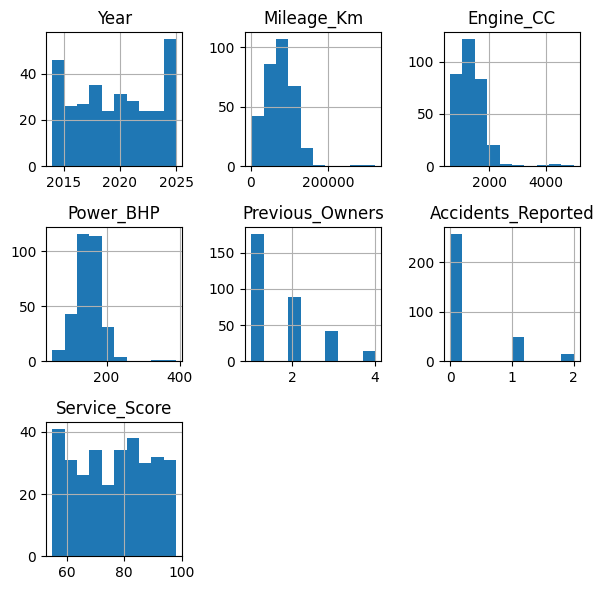

In [165]:
df[numeric_cols].hist(
    figsize=(6,6)
)

plt.tight_layout()

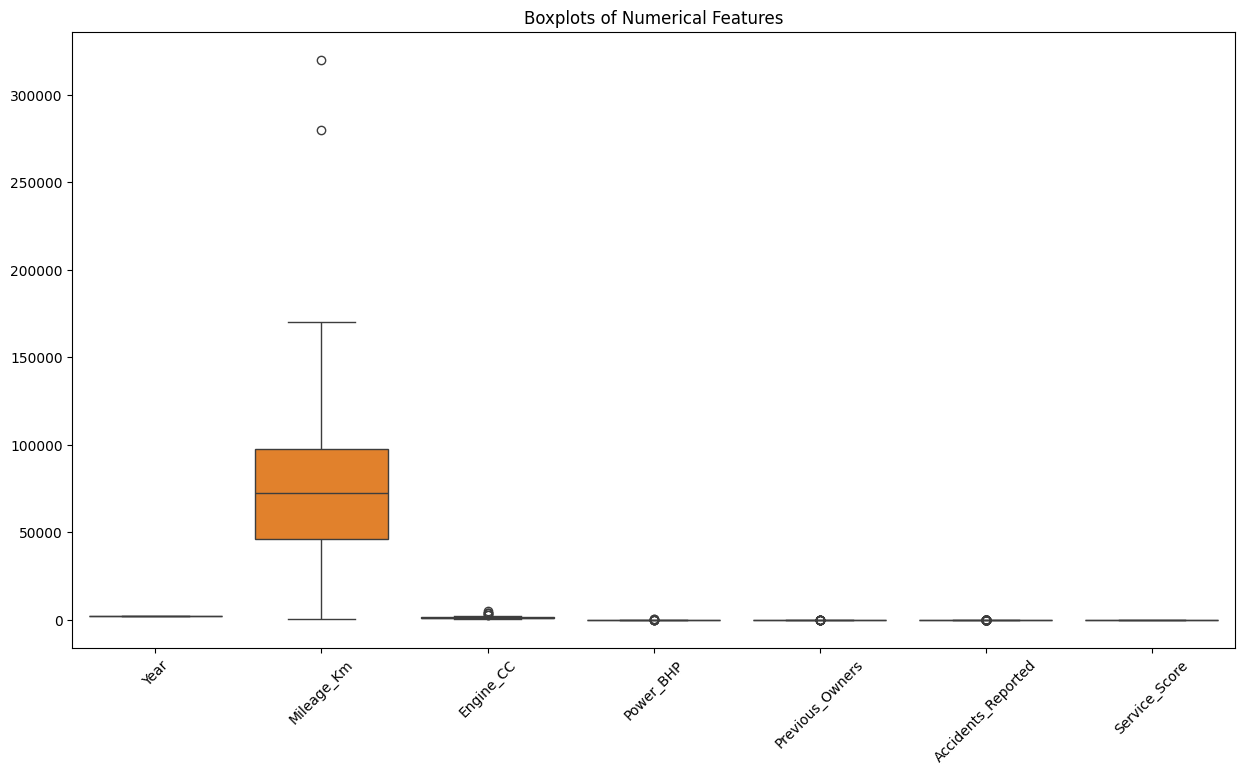

In [166]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [167]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.20,random_state=42
)

print("training shape:",x.shape)
print("test shape:",y.shape)

training shape: (320, 14)
test shape: (320,)


In [168]:
outlier_features = [
    "Mileage_Km",
    "Engine_CC",
    "Power_BHP"
]

In [169]:
iqr_bounds={}

for columns in outlier_features:

  q1 = x_train[columns].quantile(0.25)
  q3= x_train[columns].quantile(0.75)

  IQR = q3-q1

  lower_bound = q1-1.5*IQR
  upper_bound = q3+1.5*IQR

  iqr_bounds[columns]=(
      lower_bound,upper_bound
  )

  print("\n", columns)
  print("Q1:", q1)
  print("Q3:", q3)
  print("IQR:", IQR)
  print("Lower Bound:", lower_bound)
  print("Upper Bound:", upper_bound)


 Mileage_Km
Q1: 46076.75
Q3: 97695.75
IQR: 51619.0
Lower Bound: -31351.75
Upper Bound: 175124.25

 Engine_CC
Q1: 1013.25
Q3: 1644.75
IQR: 631.5
Lower Bound: 66.0
Upper Bound: 2592.0

 Power_BHP
Q1: 129.67499999999998
Q3: 171.15
IQR: 41.47500000000002
Lower Bound: 67.46249999999995
Upper Bound: 233.36250000000004


In [170]:
for column, (lower, upper) in iqr_bounds.items():

    outliers = x_train[
        (x_train[column] < lower) |
        (x_train[column] > upper)
    ]

    print(
        column,
        "outliers:",
        len(outliers)
    )

Mileage_Km outliers: 2
Engine_CC outliers: 6
Power_BHP outliers: 5


In [171]:
x_train_capped = x_train.copy()
x_test_capped = x_test.copy()

for column, (lower, upper) in iqr_bounds.items():

    x_train_capped[column] = x_train_capped[
        column
    ].clip(
        lower=lower,
        upper=upper
    )

    x_test_capped[column] = x_test_capped[
        column
    ].clip(
        lower=lower,
        upper=upper
    )

In [172]:
x.select_dtypes(include="object").columns

Index(['Car_ID', 'Brand', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type',
       'Condition'],
      dtype='object')

In [173]:
nominal_features = [
    "Brand",
    "Fuel_Type",
    "Transmission",
    "City",
    "Seller_Type"
]
ordinal_features = [
    "Condition"
]

In [174]:
numeric_features = [
    "Year",
    "Mileage_Km",
    "Engine_CC",
    "Power_BHP",
    "Previous_Owners",
    "Accidents_Reported",
    "Service_Score"
]

nominal_features = [
    "Brand",
    "Fuel_Type",
    "Transmission",
    "City",
    "Seller_Type"
]

ordinal_features = [
    "Condition"
]

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    [
                        "Poor",
                        "Fair",
                        "Good",
                        "Very Good",
                        "Excellent"
                    ]
                ]
            ),
            ordinal_features
        )
    ]
)

In [175]:
x_train_processed = preprocessor.fit_transform(
    x_train_capped
)
x_test_processed = preprocessor.transform(
    x_test_capped
)

In [176]:
feature_names = preprocessor.get_feature_names_out()

x_train_processed = pd.DataFrame(
    x_train_processed,
    columns=feature_names,
    index=x_train.index
)

x_test_processed = pd.DataFrame(
    x_test_processed,
    columns=feature_names,
    index=x_test.index
)

In [177]:
train_processed = x_train_processed.copy()
train_processed["Resale_Price_Lakh"] = y_train

test_processed = x_test_processed.copy()
test_processed["Resale_Price_Lakh"] = y_test

In [178]:
print("Train shape:", train_processed.shape)
print("Test shape:", test_processed.shape)
print("Train missing values:",train_processed.isnull().sum().sum())
print("Test missing values:",test_processed.isnull().sum().sum())

Train shape: (256, 38)
Test shape: (64, 38)
Train missing values: 0
Test missing values: 0


In [179]:
train_processed.to_csv(
    "Used_Car_Train_Preprocessed.csv",
    index=False
)

test_processed.to_csv(
    "Used_Car_Test_Preprocessed.csv",
    index=False
)